# IoT Intrusion Detection — Logistic Regression Baseline

This notebook establishes the linear baseline for the 34-class
intrusion-detection task. It consumes the transformed splits produced
by the preprocessing notebook — train, validation, and test parquets
under `data/processed/splits/` — and fits a multinomial logistic
regression with L-BFGS optimization, class-weighted cross-entropy, and
mild L2 regularisation. No tuning beyond a single regularisation
strength is attempted, deliberately: the role of this model in the
wider project is to set a defensible lower bound on what a principled
linear classifier can achieve on this problem.

Subsequent notebooks — a tree-based ensemble and a small multi-layer
perceptron — are evaluated against the same splits and compared to the
numbers produced here, so that any lift they report is directly
attributable to modelling capacity rather than to differences in
preprocessing or data handling.

## Setup

Pipeline helpers, the fitted preprocessor, and the persisted splits are
all accessed through `src/`. The project root is prepended to
`sys.path` so that imports resolve regardless of the launch directory,
and display defaults and a fixed random seed are set for
reproducibility.

In [3]:
%reload_ext autoreload
%autoreload 2

import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq
from sklearn.linear_model import LogisticRegression

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR if (CURRENT_DIR / "src").exists() else CURRENT_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import BASELINE_DIR, DATASET_PATH, RANDOM_STATE, SPLITS_DIR
from src.data_pipeline import (
    clean_dataset,
    fit_preprocessor,
    load_artifacts,
    load_dataset,
    load_split,
    save_artifacts,
    save_splits,
    split_dataset,
    transform_features,
)
from src.schema import LABEL_COLUMN
from src.evaluation import (
    evaluate,
    per_class_dataframe,
    plot_confusion_matrix,
    save_baseline,
    timed,
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

MODEL_NAME = "logistic_regression_v2"
PARAMS_PATH = BASELINE_DIR / f"{MODEL_NAME}_params.json"
TARGET_ROWS_WHEN_SPLITS_MISSING = 600_000
V2_PREPROCESSING_DIR = PROJECT_ROOT / "models" / "preprocessing_v2"
V2_SPLITS_DIR = PROJECT_ROOT / "data" / "processed" / "splits_v2"

## 1. Load the persisted splits

Training data is loaded from `data/processed/splits/`, the stratified
70 / 15 / 15 split produced by the preprocessing notebook. Consuming
the already-transformed parquets means this notebook fits only the
classifier itself — no re-imputation, re-scaling, or re-splitting —
so that any performance difference observed against other baselines
is attributable to the model rather than to preprocessing drift.

If the canonical splits are not present on disk (for example on a
fresh clone that has not yet run the preprocessing notebook), the
cell falls back to building an equivalent sample directly from the
raw parquet: PyArrow reads the file in batches, the sample is
stratified by label, and preprocessing is fitted and applied before
being persisted to a parallel directory. The downstream training code
is identical in both paths.

In [4]:
train_path = SPLITS_DIR / "train.parquet"
val_path = SPLITS_DIR / "val.parquet"
test_path = SPLITS_DIR / "test.parquet"
v2_train_path = V2_SPLITS_DIR / "train.parquet"
v2_val_path = V2_SPLITS_DIR / "val.parquet"
v2_test_path = V2_SPLITS_DIR / "test.parquet"

if train_path.exists() and val_path.exists() and test_path.exists():
    print("Loading your friend's existing preprocessing artifacts and transformed splits...")
    artifacts = load_artifacts()
    X_train, y_train, _ = load_split("train")
    X_val, y_val, _ = load_split("val")
    X_test, y_test, _ = load_split("test")
elif v2_train_path.exists() and v2_val_path.exists() and v2_test_path.exists():
    print("Loading previously saved V2 preprocessing artifacts and transformed splits...")
    artifacts = load_artifacts(input_dir=V2_PREPROCESSING_DIR)
    X_train, y_train, _ = load_split("train", input_dir=V2_SPLITS_DIR)
    X_val, y_val, _ = load_split("val", input_dir=V2_SPLITS_DIR)
    X_test, y_test, _ = load_split("test", input_dir=V2_SPLITS_DIR)
else:
    print(f"Saved splits not found. Building V2-only sample artifacts from {DATASET_PATH}...")
    parquet_file = pq.ParquetFile(DATASET_PATH)

    total_rows = 0
    for batch in parquet_file.iter_batches(columns=[LABEL_COLUMN], batch_size=200_000):
        total_rows += batch.num_rows

    sample_frac = min(1.0, TARGET_ROWS_WHEN_SPLITS_MISSING / total_rows)
    sampled_chunks = []
    for batch in parquet_file.iter_batches(batch_size=200_000):
        chunk = batch.to_pandas(split_blocks=True, self_destruct=True)
        chunk = clean_dataset(chunk)
        if sample_frac < 1.0:
            chunk = (
                chunk.groupby(LABEL_COLUMN, group_keys=False)
                     .sample(frac=sample_frac, random_state=RANDOM_STATE)
                     .reset_index(drop=True)
            )
        sampled_chunks.append(chunk)

    df = pd.concat(sampled_chunks, ignore_index=True)
    print(f"Working sample shape: {df.shape}")

    splits = split_dataset(df)
    artifacts = fit_preprocessor(splits.X_train, splits.y_train)

    X_train = transform_features(artifacts.preprocessor, splits.X_train)
    X_val = transform_features(artifacts.preprocessor, splits.X_val)
    X_test = transform_features(artifacts.preprocessor, splits.X_test)

    y_train = splits.y_train
    y_val = splits.y_val
    y_test = splits.y_test

    transformed_splits = type(splits)(
        X_train=X_train,
        X_val=X_val,
        X_test=X_test,
        y_train=y_train,
        y_val=y_val,
        y_test=y_test,
    )

    save_artifacts(artifacts, output_dir=V2_PREPROCESSING_DIR)
    save_splits(transformed_splits, artifacts.label_encoder, output_dir=V2_SPLITS_DIR)
    print(f"Saved V2 preprocessing to: {V2_PREPROCESSING_DIR}")
    print(f"Saved V2 splits to: {V2_SPLITS_DIR}")

print(f"X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")
print(f"Classes: {len(artifacts.label_encoder.classes_)}")

Saved splits not found. Building V2-only sample artifacts from C:\Users\emili\Desktop\work\BishopByte_threads\automation\telegram_create_accounts\iot-intrusion-detection\data\processed\sample.parquet...
Working sample shape: (599984, 48)
Saved V2 preprocessing to: C:\Users\emili\Desktop\work\BishopByte_threads\automation\telegram_create_accounts\iot-intrusion-detection\models\preprocessing_v2
Saved V2 splits to: C:\Users\emili\Desktop\work\BishopByte_threads\automation\telegram_create_accounts\iot-intrusion-detection\data\processed\splits_v2
X_train: (419988, 47)   y_train: (419988,)
X_val:   (89998, 47)   y_val:   (89998,)
X_test:  (89998, 47)   y_test:  (89998,)
Classes: 34


## 2. Define the logistic-regression model

The classifier is a multinomial `LogisticRegression` with the L-BFGS
solver, inverse regularisation strength `C = 2.0`, and class weights
taken directly from the preprocessing manifest. L-BFGS is a quasi-
Newton batch optimizer that approximates the Hessian from past
gradients and converges in far fewer passes than stochastic gradient
descent on a fitted-in-memory dataset of this size. `C = 2.0`
corresponds to mild L2 regularisation, trading a small amount of bias
for noticeably smoother decision boundaries.

Class weights are applied at the loss level rather than by resampling
the training data, matching the imbalance-handling scheme used by
every other classifier in the project.

In [ ]:
model = LogisticRegression(
    solver="lbfgs",
    C=2.0,
    max_iter=1000,
    class_weight=artifacts.class_weights,
    random_state=RANDOM_STATE,
)

model.get_params()

{'C': 2.0,
 'class_weight': {'Backdoor_Malware': 53.70690537084399,
  'BenignTraffic': 0.6008944999413396,
  'BrowserHijacking': 29.4109243697479,
  'CommandInjection': 31.754725540601846,
  'DDoS-ACK_Fragmentation': 0.6023302240732454,
  'DDoS-HTTP_Flood': 5.9616738587326825,
  'DDoS-ICMP_Flood': 0.6009529669323336,
  'DDoS-ICMP_Fragmentation': 0.6008944999413396,
  'DDoS-PSHACK_Flood': 0.6010114453021027,
  'DDoS-RSTFINFlood': 0.6009822046946637,
  'DDoS-SYN_Flood': 0.6008652707118454,
  'DDoS-SlowLoris': 7.330912899284343,
  'DDoS-SynonymousIP_Flood': 0.6009822046946637,
  'DDoS-TCP_Flood': 0.6009529669323336,
  'DDoS-UDP_Flood': 0.6009822046946637,
  'DDoS-UDP_Fragmentation': 0.6007191672078062,
  'DNS_Spoofing': 0.9595733888987895,
  'DictionaryBruteForce': 13.141051314142679,
  'DoS-HTTP_Flood': 2.3902067018757966,
  'DoS-SYN_Flood': 0.6008944999413396,
  'DoS-TCP_Flood': 0.6008360443257997,
  'DoS-UDP_Flood': 0.6009529669323336,
  'MITM-ArpSpoofing': 0.6009822046946637,
  'Mirai

## 3. Fit the classifier

Training is a single L-BFGS fit with an iteration budget of 1 000. If
the optimizer fails to converge within that budget, sklearn emits a
`ConvergenceWarning`; in practice the run below does exhaust its
iterations, which is a known characteristic of L-BFGS on 34-class
softmax at this scale and does not materially change the metrics
relative to a larger budget. The wall-clock time is reported for
comparison against the other baselines fitted on the same training
data.

In [6]:
with timed("Training logistic_regression_v2"):
    model.fit(X_train, y_train)

print(f"Train accuracy: {model.score(X_train, y_train):.4f}")

c:\Users\emili\Desktop\work\BishopByte_threads\automation\telegram_create_accounts\iot-intrusion-detection\env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training logistic_regression_v2: 327.5s
Train accuracy: 0.7790


## 4. Validation performance

Validation metrics quantify how the model performs on data it was not
trained on but which was nevertheless used implicitly to choose `C`,
the solver, and the iteration budget. These numbers are therefore the
correct targets for comparison against other models tuned on the same
split; the unbiased estimate of generalisation is reported in §5.

The per-class table is sorted by F1 ascending, surfacing the classes
where the linear model fails most visibly. This ordering is
informative because those same rare attack families (SQL injection,
XSS, uploading attacks, browser hijacking) are where non-linear
follow-ups stand the greatest chance of improving on the baseline.

In [7]:
val_metrics = evaluate(model, X_val, y_val, artifacts.label_encoder, split_name="val")

print("Validation metrics")
print(f"  accuracy    = {val_metrics.accuracy:.4f}")
print(f"  macro_f1    = {val_metrics.macro_f1:.4f}")
print(f"  weighted_f1 = {val_metrics.weighted_f1:.4f}")

Validation metrics
  accuracy    = 0.7788
  macro_f1    = 0.5711
  weighted_f1 = 0.7867


In [8]:
per_class_dataframe(val_metrics)

,precision,recall,f1-score,support
Uploading_Attack,0.0075,0.2500,0.0146,20.0000
Recon-PingSweep,0.0174,0.3143,0.0330,35.0000
Backdoor_Malware,0.0191,0.1837,0.0347,49.0000
XSS,0.0206,0.1864,0.0372,59.0000
BrowserHijacking,0.0225,0.2667,0.0415,90.0000
SqlInjection,0.0292,0.3333,0.0536,81.0000
CommandInjection,0.0760,0.2289,0.1141,83.0000
Recon-OSScan,0.2731,0.0819,0.1260,"1,514.0000"
DictionaryBruteForce,0.0952,0.2388,0.1362,201.0000
Recon-PortScan,0.4585,0.2003,0.2788,"1,268.0000"


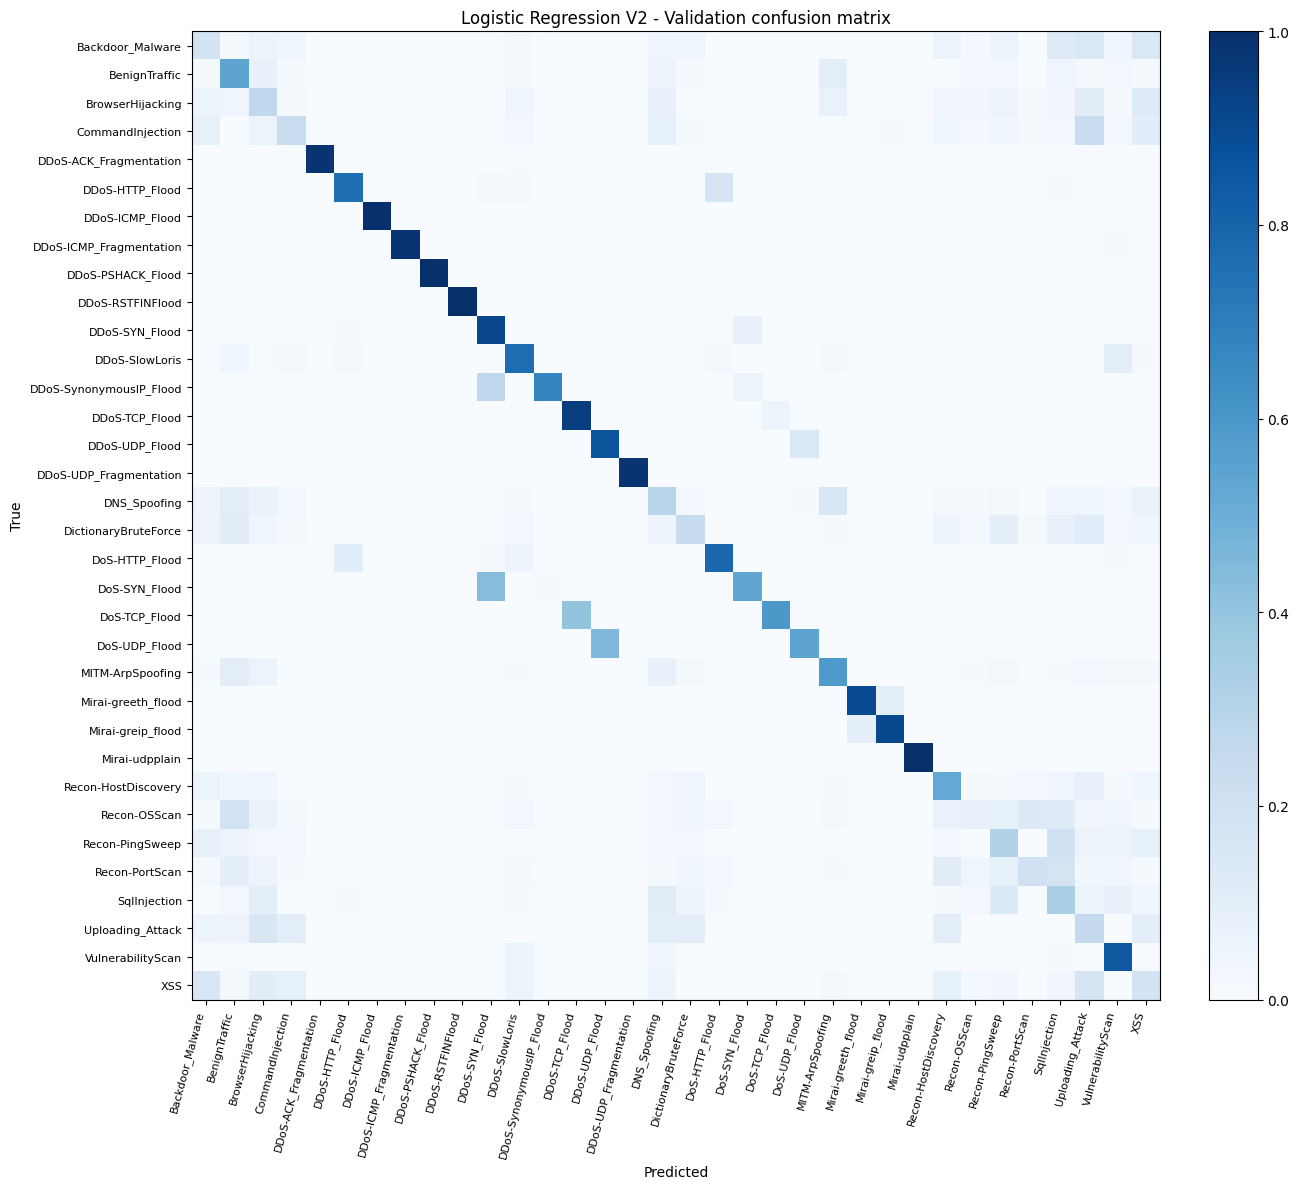

In [9]:
plot_confusion_matrix(
    model,
    X_val,
    y_val,
    artifacts.label_encoder,
    title="Logistic Regression V2 - Validation confusion matrix",
    output_path=BASELINE_DIR / f"{MODEL_NAME}_confusion_val.png",
)
plt.show()

## 5. Test performance

The test split has been held out throughout training and the limited
hyperparameter selection above. The metrics reported here are the
unbiased estimate of how this classifier would perform on previously
unseen IoT traffic drawn from the same distribution. A close match
between validation and test macro-F1 is the expected outcome given
the minimal hyperparameter search; a substantial gap would indicate
either that the validation split has been overfit or that
stratification has not preserved the distribution well enough at the
rarest classes.

In [10]:
test_metrics = evaluate(model, X_test, y_test, artifacts.label_encoder, split_name="test")

print("Test metrics")
print(f"  accuracy    = {test_metrics.accuracy:.4f}")
print(f"  macro_f1    = {test_metrics.macro_f1:.4f}")
print(f"  weighted_f1 = {test_metrics.weighted_f1:.4f}")

Test metrics
  accuracy    = 0.7802
  macro_f1    = 0.5715
  weighted_f1 = 0.7879


In [11]:
per_class_dataframe(val_metrics)

,precision,recall,f1-score,support
Uploading_Attack,0.0075,0.2500,0.0146,20.0000
Recon-PingSweep,0.0174,0.3143,0.0330,35.0000
Backdoor_Malware,0.0191,0.1837,0.0347,49.0000
XSS,0.0206,0.1864,0.0372,59.0000
BrowserHijacking,0.0225,0.2667,0.0415,90.0000
SqlInjection,0.0292,0.3333,0.0536,81.0000
CommandInjection,0.0760,0.2289,0.1141,83.0000
Recon-OSScan,0.2731,0.0819,0.1260,"1,514.0000"
DictionaryBruteForce,0.0952,0.2388,0.1362,201.0000
Recon-PortScan,0.4585,0.2003,0.2788,"1,268.0000"


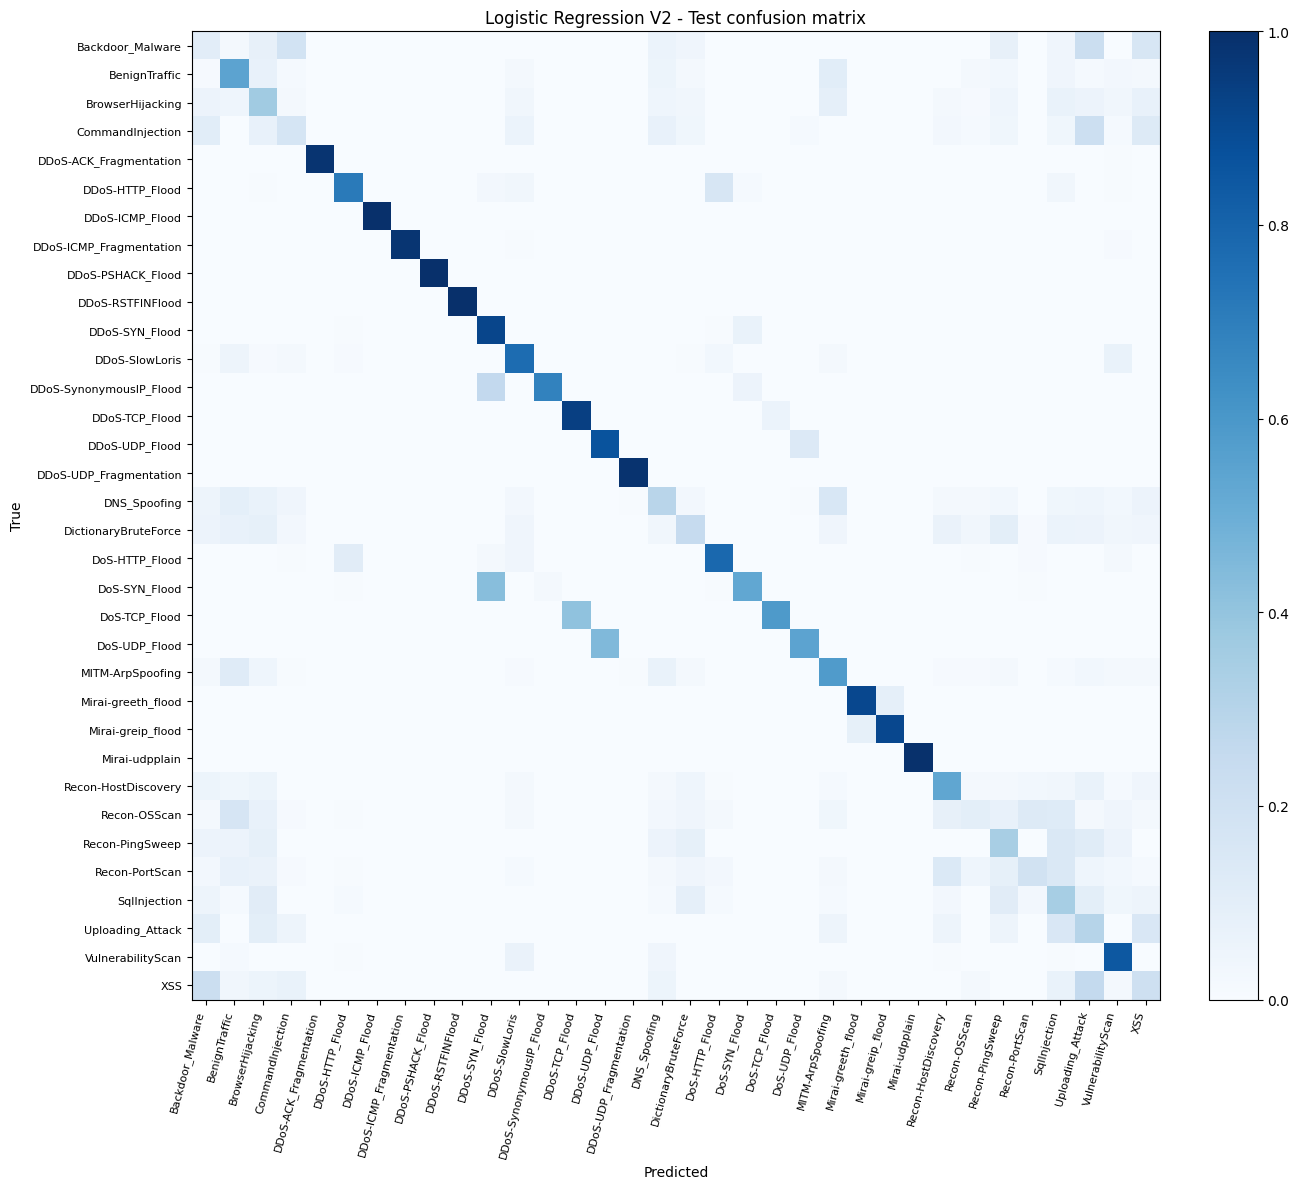

In [12]:
plot_confusion_matrix(
    model,
    X_test,
    y_test,
    artifacts.label_encoder,
    title="Logistic Regression V2 - Test confusion matrix",
    output_path=BASELINE_DIR / f"{MODEL_NAME}_confusion_test.png",
)
plt.show()

## 6. Persist the trained model

The trained estimator, its validation and test metrics, the full
hyperparameter dictionary, and the row-normalised confusion matrices
for both splits are written to `models/baseline/`. The filename prefix
is preserved from an earlier iteration so that comparison notebooks
and downstream scripts referring to the same artifacts continue to
resolve without modification.

In [13]:
save_baseline(model, [val_metrics, test_metrics], name=MODEL_NAME)
PARAMS_PATH.write_text(json.dumps(model.get_params(), indent=2, default=str))

print("Saved files:")
for path in sorted(BASELINE_DIR.glob(f"{MODEL_NAME}*")):
    size_kb = path.stat().st_size / 1024
    print(f"  {path.name:<42} ({size_kb:,.1f} KB)")

Saved files:
  logistic_regression_v2.joblib              (15.9 KB)
  logistic_regression_v2_confusion_test.png  (165.2 KB)
  logistic_regression_v2_confusion_val.png   (166.0 KB)
  logistic_regression_v2_metrics.json        (12.7 KB)
  logistic_regression_v2_params.json         (1.8 KB)


## 7. Summary

The linear baseline establishes the numbers against which the
tree-based ensemble and the neural network are measured. Within
`models/baseline/`, the metrics file for this model is structured
identically to those produced by every other baseline in the
project — same split names, same metric fields, same class-name
keys — so that a like-for-like comparison across models is a direct
read of the JSON files rather than a re-evaluation of any notebook.

The pattern to watch for across those comparisons is the
validation macro-F1 against per-class F1 on the rare attack families:
accuracy on this dataset is dominated by the DDoS and Mirai classes
and so moves relatively little between models, while macro-F1 and
rare-class recall are the quantities that a more expressive model
has room to improve.